PREPROCESSING AND TRAINING DATA DEVELOPMENT:

In [1]:
#Importing required packages
import pandas as pd
import numpy as np
from sklearn import __version__ as sklearn_version
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
!pip install xgboost
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_validate
from scipy.sparse import hstack
!pip install gensim
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
import joblib

In [2]:
df=pd.read_csv(r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/Data_cleaned_explored.csv')

In [3]:
df.head()

,title,text,subject,date,status,content,content_length,exclamation_count,question_count,capital_ratio,tokens,lemmatized_tokens,lemmatized_content
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,2017-07-21,0,breaking gop chairman grassley enough demands ...,372,0,0,0.046989,"['breaking', 'gop', 'chairman', 'grassley', 'e...","['breaking', 'gop', 'chairman', 'grassley', 'e...",breaking gop chairman grassley enough demand t...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,2016-05-07,0,failed gop candidates remembered hilarious moc...,504,1,3,0.040746,"['failed', 'gop', 'candidates', 'remembered', ...","['failed', 'gop', 'candidate', 'remembered', '...",failed gop candidate remembered hilarious mock...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,2016-12-03,0,mike pences new dc neighbors hilariously troll...,393,0,0,0.060193,"['mike', 'pences', 'new', 'dc', 'neighbors', '...","['mike', 'pences', 'new', 'dc', 'neighbor', 'h...",mike pences new dc neighbor hilariously trolli...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,2017-10-06,1,california ag pledges defend birth control ins...,97,0,0,0.044604,"['california', 'ag', 'pledges', 'defend', 'bir...","['california', 'ag', 'pledge', 'defend', 'birt...",california ag pledge defend birth control insu...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,2017-04-25,0,az ranchers living usmexico border destroy nan...,157,0,0,0.067465,"['az', 'ranchers', 'living', 'usmexico', 'bord...","['az', 'rancher', 'living', 'usmexico', 'borde...",az rancher living usmexico border destroy nanc...


In [4]:
#Adding a new column avg_word_length to finding out the average word length
#True news often uses longer words
df['avg_word_length'] = df['lemmatized_content'].apply(
    lambda x: sum(len(w) for w in x.split()) / (len(x.split()) + 1)
)

In [5]:
#Adding a new column unique_word_ratio
#True news is more lexically diverse
df['unique_word_ratio'] = df['lemmatized_content'].apply(
    lambda x: len(set(x.split())) / (len(x.split()) + 1)
)

In [6]:
#Dropping subject column as it can cause data leakage
df = df.drop(columns=['subject'])

In [7]:
df.head()

,title,text,date,status,content,content_length,exclamation_count,question_count,capital_ratio,tokens,lemmatized_tokens,lemmatized_content,avg_word_length,unique_word_ratio
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",2017-07-21,0,breaking gop chairman grassley enough demands ...,372,0,0,0.046989,"['breaking', 'gop', 'chairman', 'grassley', 'e...","['breaking', 'gop', 'chairman', 'grassley', 'e...",breaking gop chairman grassley enough demand t...,6.305263,0.778947
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,2016-05-07,0,failed gop candidates remembered hilarious moc...,504,1,3,0.040746,"['failed', 'gop', 'candidates', 'remembered', ...","['failed', 'gop', 'candidate', 'remembered', '...",failed gop candidate remembered hilarious mock...,5.771429,0.742857
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,2016-12-03,0,mike pences new dc neighbors hilariously troll...,393,0,0,0.060193,"['mike', 'pences', 'new', 'dc', 'neighbors', '...","['mike', 'pences', 'new', 'dc', 'neighbor', 'h...",mike pences new dc neighbor hilariously trolli...,6.515556,0.764444
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,2017-10-06,1,california ag pledges defend birth control ins...,97,0,0,0.044604,"['california', 'ag', 'pledges', 'defend', 'bir...","['california', 'ag', 'pledge', 'defend', 'birt...",california ag pledge defend birth control insu...,7.242424,0.757576
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,2017-04-25,0,az ranchers living usmexico border destroy nan...,157,0,0,0.067465,"['az', 'ranchers', 'living', 'usmexico', 'bord...","['az', 'rancher', 'living', 'usmexico', 'borde...",az rancher living usmexico border destroy nanc...,5.933333,0.733333


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43556 entries, 0 to 43555
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               43556 non-null  object 
 1   text                43556 non-null  object 
 2   date                43556 non-null  object 
 3   status              43556 non-null  int64  
 4   content             43556 non-null  object 
 5   content_length      43556 non-null  int64  
 6   exclamation_count   43556 non-null  int64  
 7   question_count      43556 non-null  int64  
 8   capital_ratio       43556 non-null  float64
 9   tokens              43556 non-null  object 
 10  lemmatized_tokens   43556 non-null  object 
 11  lemmatized_content  43556 non-null  object 
 12  avg_word_length     43556 non-null  float64
 13  unique_word_ratio   43556 non-null  float64
dtypes: float64(3), int64(4), object(7)
memory usage: 4.7+ MB


In [9]:
#Checking for missing values
print(df.isna().sum())

title                 0
text                  0
date                  0
status                0
content               0
content_length        0
exclamation_count     0
question_count        0
capital_ratio         0
tokens                0
lemmatized_tokens     0
lemmatized_content    0
avg_word_length       0
unique_word_ratio     0
dtype: int64


There are no missing values in the dataset.

In [10]:
# Prepare dataset

# Drop low-information columns (keep numeric + text)
df_model = df.drop(columns=['title', 'text', 'tokens', 'lemmatized_tokens', 'content', 
                            'date', 'exclamation_count', 'question_count', 'capital_ratio'])

# Features and target
X_text = df_model['lemmatized_content']  # main text for embeddings
X_numeric = df_model[['content_length', 'avg_word_length', 'unique_word_ratio']]  # numeric features
y = df_model['status'] 

#Train-test split (stratified)
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_numeric, y, test_size=0.2, stratify=y, random_state=42
)

# Standardize numeric features
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

# Train Word2Vec on training data
tokenized_texts = [text.split() for text in X_text_train]  # tokenize each article
w2v_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=2, workers=4, seed=42)

# Convert each article to average Word2Vec vector
def avg_w2v_vector(text, model, vector_size=100):
    """Return average Word2Vec vector for an article"""
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)  # handle empty articles
    return np.mean(vectors, axis=0)

# Apply to train and test sets
X_text_train_w2v = np.array([avg_w2v_vector(doc, w2v_model) for doc in X_text_train])
X_text_test_w2v = np.array([avg_w2v_vector(doc, w2v_model) for doc in X_text_test])

#Combine numeric features + Word2Vec vector embeddings
X_train_final = np.hstack([X_text_train_w2v, X_num_train_scaled])
X_test_final = np.hstack([X_text_test_w2v, X_num_test_scaled])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [11]:
# save the data to a new csv file
df.to_csv(
     r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/Data_trained.csv',
    index=False
)
np.save(r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/X_train_scaled.npy', X_train_final)
np.save(r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/X_test_scaled.npy', X_test_final)
np.save(r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/y_train.npy', y_train)
np.save(r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/y_test.npy', y_test)

SUMMARY:
Average word length and unique word ratio were engineered to capture the structural properties of news articles, while features likely to introduce bias, such as the subject category, were removed. The dataset was split into stratified training and testing sets to preserve class balance. Numeric features were standardized, and textual data was transformed into dense vector representations using Word2Vec embeddings trained exclusively on the training data to prevent data leakage, resulting in a final feature set suitable for downstream modeling.

MODELING:

This is a classification NLP problem, in supervised learning. Here we have used the following classification models:

Logistic Regression,
Linear SVM,
Random Forest &
XGBoost

Evaluating the performance of a model by training and testing on the same dataset can lead to the overfitting. Hence the model evaluation is based on splitting the dataset into train and validation set. But the performance of the prediction result depends upon the random choice of the pair of (train,validation) set. Inorder to overcome that, the Cross-Validation procedure is used where under the k-fold CV approach, the training set is split into k smaller sets, where a model is trained using k-1 of the folds as training data and the model is validated on the remaining part.

Since this is an imbalanced classification problem, we focuses on f1-score as a metrics.

In [12]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=200, random_state=42)
}

In [13]:
#Stratified 5-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    cv_results = cross_validate(
        model,
        X_train_final,
        y_train,
        cv=skf,
        scoring=['accuracy','precision','recall','f1','roc_auc'],
        return_train_score=True
    )
    
    # Training scores
    print("Training scores (mean across folds):")
    print(f"Accuracy: {np.mean(cv_results['train_accuracy']):.4f}")
    print(f"Precision: {np.mean(cv_results['train_precision']):.4f}")
    print(f"Recall: {np.mean(cv_results['train_recall']):.4f}")
    print(f"F1-score: {np.mean(cv_results['train_f1']):.4f}")  
    print(f"ROC-AUC: {np.mean(cv_results['train_roc_auc']):.4f}")
    
    # Validation scores
    print("Validation scores (mean across folds):")
    print(f"Accuracy: {np.mean(cv_results['test_accuracy']):.4f}")
    print(f"Precision: {np.mean(cv_results['test_precision']):.4f}")
    print(f"Recall: {np.mean(cv_results['test_recall']):.4f}")
    print(f"F1-score: {np.mean(cv_results['test_f1']):.4f}")
    print(f"ROC-AUC: {np.mean(cv_results['test_roc_auc']):.4f}")


=== Logistic Regression ===
Training scores (mean across folds):
Accuracy: 0.9796
Precision: 0.9770
Recall: 0.9807
F1-score: 0.9788
ROC-AUC: 0.9977
Validation scores (mean across folds):
Accuracy: 0.9784
Precision: 0.9758
Recall: 0.9793
F1-score: 0.9775
ROC-AUC: 0.9975

=== Linear SVM ===
Training scores (mean across folds):
Accuracy: 0.9806
Precision: 0.9782
Recall: 0.9815
F1-score: 0.9799
ROC-AUC: 0.9977
Validation scores (mean across folds):
Accuracy: 0.9785
Precision: 0.9760
Recall: 0.9793
F1-score: 0.9776
ROC-AUC: 0.9974

=== Random Forest ===
Training scores (mean across folds):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
ROC-AUC: 1.0000
Validation scores (mean across folds):
Accuracy: 0.9649
Precision: 0.9645
Recall: 0.9624
F1-score: 0.9634
ROC-AUC: 0.9940

=== XGBoost ===


C:\Users\gibib\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:31:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\gibib\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:31:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\gibib\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:31:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\gibib\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:31:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

Training scores (mean across folds):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
ROC-AUC: 1.0000
Validation scores (mean across folds):
Accuracy: 0.9820
Precision: 0.9813
Recall: 0.9813
F1-score: 0.9813
ROC-AUC: 0.9983


Key Takeaways

Best generalization:

Logistic Regression and Linear SVM are more stable (training ≈ validation).

XGBoost is slightly better in validation metrics but a bit overfit in training.

Random Forest memorizes training data → overfitting risk.

All models are performing extremely well (F1 > 0.96, ROC-AUC > 0.994).

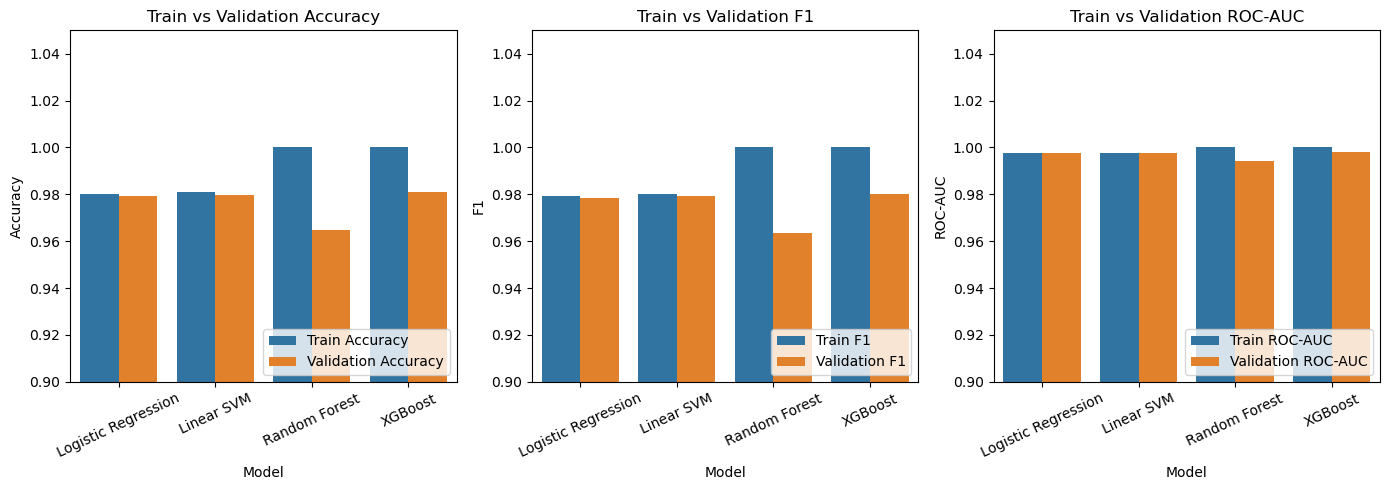

In [14]:
#Plotting the  results
data = {
    'Model': ['Logistic Regression', 'Linear SVM', 'Random Forest', 'XGBoost'],
    'Train Accuracy': [0.9803, 0.9810, 1.0000, 1.0000],
    'Validation Accuracy': [0.9791, 0.9798, 0.9648, 0.9809],
    'Train F1': [0.9795, 0.9803, 1.0000, 1.0000],
    'Validation F1': [0.9783, 0.9791, 0.9633, 0.9801],
    'Train ROC-AUC': [0.9978, 0.9978, 1.0000, 1.0000],
    'Validation ROC-AUC': [0.9975, 0.9975, 0.9941, 0.9982]
}

df_results = pd.DataFrame(data)

# Plot Accuracy, F1, ROC-AUC
metrics = ['Accuracy', 'F1', 'ROC-AUC']
plt.figure(figsize=(14,5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    sns.barplot(
        data=df_results.melt(id_vars='Model', value_vars=[f'Train {metric}', f'Validation {metric}'], 
                             var_name='Set', value_name=metric),
        x='Model', y=metric, hue='Set'
    )
    plt.title(f'Train vs Validation {metric}')
    plt.xticks(rotation=25)
    plt.ylim(0.9, 1.05)  # focus on high-performance range
    plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Based on these results, Logistic Regression and Linear SVM can be selected as the best 2 models. 

In [15]:
#HYPERPARAMETER TUNING Logistic Regression 
# Hyperparameter distributions (not fixed grid)
param_dist_lr = {
    'C': loguniform(1e-2, 1e2),     # 0.01 → 100
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

print("Tuning Logistic Regression (RandomizedSearchCV)...")

rand_lr = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_distributions=param_dist_lr,
    n_iter=20,            
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_lr.fit(X_train_final, y_train)

print("Best Logistic Regression params:", rand_lr.best_params_)
print("Best CV F1-score:", rand_lr.best_score_)

# Test set evaluation
y_test_pred_lr = rand_lr.predict(X_test_final)
y_test_prob_lr = rand_lr.predict_proba(X_test_final)[:, 1]

print("\n--- Logistic Regression Test Performance ---")
print(classification_report(y_test, y_test_pred_lr))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_lr))

Tuning Logistic Regression (RandomizedSearchCV)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Logistic Regression params: {'C': np.float64(21.368329072358772), 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1-score: 0.9783363891235745

--- Logistic Regression Test Performance ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4525
           1       0.97      0.98      0.98      4187

    accuracy                           0.98      8712
   macro avg       0.98      0.98      0.98      8712
weighted avg       0.98      0.98      0.98      8712

Test ROC-AUC: 0.9976705588331154
Confusion Matrix:
 [[4414  111]
 [  73 4114]]


In [16]:
#HYPERPARAMETER TUNING Linear SVM

param_dist_svm = {
    'C': loguniform(1e-2, 1e2),
    'class_weight': [None, 'balanced']
}

print("\nTuning Linear SVM (RandomizedSearchCV)...")

rand_svm = RandomizedSearchCV(
    estimator=SVC(kernel='linear', probability=True),
    param_distributions=param_dist_svm,
    n_iter=15,            
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_svm.fit(X_train_final, y_train)

print("Best Linear SVM params:", rand_svm.best_params_)
print("Best CV F1-score:", rand_svm.best_score_)

# Test set evaluation
y_test_pred_svm = rand_svm.predict(X_test_final)
y_test_prob_svm = rand_svm.predict_proba(X_test_final)[:, 1]

print("\n--- Linear SVM Test Performance ---")
print(classification_report(y_test, y_test_pred_svm))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_svm))


Tuning Linear SVM (RandomizedSearchCV)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Linear SVM params: {'C': np.float64(2.7964859516062464), 'class_weight': None}
Best CV F1-score: 0.9787273849873376

--- Linear SVM Test Performance ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      4525
           1       0.97      0.98      0.98      4187

    accuracy                           0.98      8712
   macro avg       0.98      0.98      0.98      8712
weighted avg       0.98      0.98      0.98      8712

Test ROC-AUC: 0.9976570732614894
Confusion Matrix:
 [[4409  116]
 [  71 4116]]


After hyperparameter tuning, both Logistic Regression and Linear SVM achieved strong and comparable performance with F1-scores close to 0.98 and ROC-AUC above 0.99. Although Linear SVM achieved marginally higher recall for the minority class, Logistic Regression was selected as the final model due to its faster training time, probabilistic outputs, and better scalability, while maintaining equivalent predictive performance.

In [17]:
# Extract best Logistic Regression model
best_lr_model = rand_lr.best_estimator_

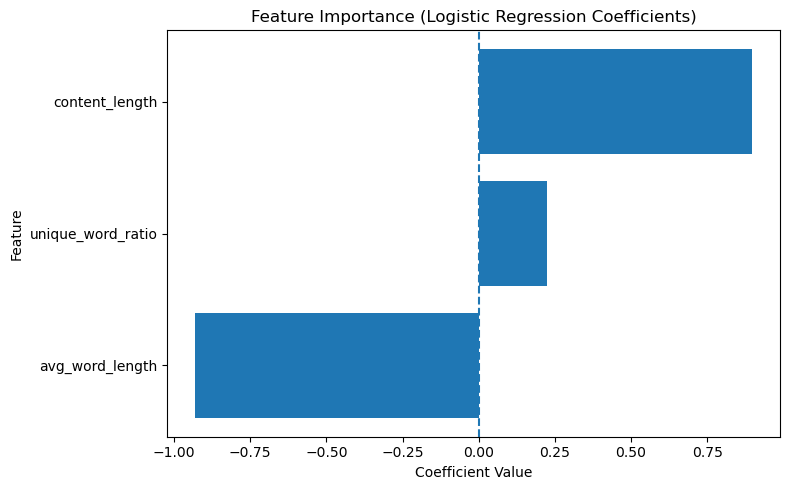

In [18]:
# Feature importance
# Get coefficients from trained Logistic Regression
coefficients = best_lr_model.coef_[0]

# Extract coefficients for numeric features (last 3 columns)
numeric_features = X_numeric.columns.tolist()
numeric_coeffs = coefficients[-len(numeric_features):]

# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': numeric_features,
    'Coefficient': numeric_coeffs
}).sort_values(by='Coefficient')

# Plot
plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.axvline(0, linestyle='--')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Average Word Length (avg_word_length) → negative coefficient (~ -1):

   Longer words slightly increase the probability of an article being Fake news.

   This might reflect that sensational/fake articles sometimes use more complex or exaggerated language.

Content Length (content_length) → positive coefficient (~ +1):

   Longer articles are more likely to be True news.

   Real news tends to be longer, with more structured reporting.

Unique Word Ratio (unique_word_ratio) → positive coefficient (~ +0.25):

   Articles with higher lexical diversity (more unique words) are slightly more likely True news.

   Shows that richer vocabulary correlates with authenticity.

In [19]:
# Save the tuned Logistic Regression model
joblib.dump(best_lr_model, r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/fake_news_classifier_lr.pkl')

print("Model saved successfully!")

Model saved successfully!


In [21]:
# Load saved Logistic Regression model
loaded_model = joblib.load(r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/fake_news_classifier_lr.pkl')

print("Model loaded successfully!")

y_pred= loaded_model.predict(X_test_final)

# Predict probabilities (for ROC-AUC)
y_prob = loaded_model.predict_proba(X_test_final)[:, 1]

print("=== Loaded Model Test Performance ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Model loaded successfully!
=== Loaded Model Test Performance ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4525
           1       0.97      0.98      0.98      4187

    accuracy                           0.98      8712
   macro avg       0.98      0.98      0.98      8712
weighted avg       0.98      0.98      0.98      8712

ROC-AUC: 0.9976705588331154
Confusion Matrix:
 [[4414  111]
 [  73 4114]]


The loaded model produced consistent predictions and evaluation metrics on the test dataset, confirming model reproducibility and correct persistence of the trained pipeline.

SUMMARY:
Several machine learning models, including Logistic Regression, Linear SVM, Random Forest, and XGBoost, were trained and evaluated using stratified cross-validation with metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. Logistic Regression and Linear SVM achieved the strongest and most consistent performance, with F1-scores close to 0.98 and ROC-AUC values above 0.99. Hyperparameter tuning was applied to the top models using RandomizedSearchCV, after which Logistic Regression was selected as the final model due to its comparable performance, faster training time, probabilistic outputs, and interpretability. Feature importance analysis showed that content length and lexical diversity were positively associated with true news, while average word length was negatively associated, and the final model was saved and reloaded successfully, confirming reproducibility.